In [1]:
import numpy as np


MANUEL HESAPLAMA FONKSİYONU(POWER ITERATION)


Referans verilen depodaki iteratif yaklaşımı baz alarak oluşturulan aşağıdaki fonksiyon, verilen bir $A$ matrisi için belirlenen iterasyon sayısı kadar döngüye girerek en büyük özdeğeri hesaplar.


In [2]:
def manuel_ozdeger_hesaplama(A,iterasyon_sayisi=100):
  # Başlangıç için rastgele bir birim vektör oluşturuyoruz
    n = A.shape[0]
    v = np.random.rand(n)
    v = v / np.linalg.norm(v) # Vektörü normalize et (boyunu 1 yap)
    for _ in range(iterasyon_sayisi):
        # Matris ile vektörü çarp (A * v)
        v_yeni = np.dot(A, v)

        # Yeni vektörün boyunu (normunu) hesapla -> Bu bizim özdeğer adayımızdır
        ozdeger = np.linalg.norm(v_yeni)

        # Vektörü bir sonraki adım için tekrar normalize et
        v = v_yeni / ozdeger

    return ozdeger, v

In [4]:
# Test için karesel bir matris tanımlayalım
A = np.array([[4, 2],
              [1, 3]])

ozdeger_manuel, ozvektor_manuel = manuel_ozdeger_hesaplama(A)

print(f"Manuel Hesaplanan En Büyük Özdeğer: {ozdeger_manuel}")
print(f"Manuel Hesaplanan Özvektör: {ozvektor_manuel}")

Manuel Hesaplanan En Büyük Özdeğer: 5.0
Manuel Hesaplanan Özvektör: [0.89442719 0.4472136 ]


### 4.1. Matematiksel Model (Power Iteration)
Kullanılan iteratif yaklaşım, baskın özdeğeri bulmak için şu yinelemeli formülü temel alır:

$$b_{k+1} = \frac{A b_k}{\|A b_k\|}$$

Burada her $k$ iterasyonu sonunda elde edilen $\|A b_k\|$ değeri, matrisin en büyük özdeğerine ($\lambda_{max}$) yakınsar.

NUMPY linealg.eig İLE KARSILASTIRMA

Ödevin gereksinimleri doğrultusunda, aynı matrisi NumPy'ın profesyonel fonksiyonuyla test ediyoruz.

In [5]:
# NumPy ile hesaplama
ozdegerler_np, ozvektorler_np = np.linalg.eig(A)

# En büyük özdeğeri bulalım (NumPy tüm özdeğerleri liste olarak döndürür)
max_idx = np.argmax(ozdegerler_np)
ozdeger_np_max = ozdegerler_np[max_idx]
ozvektor_np_max = ozvektorler_np[:, max_idx]

print(f"\nNumPy ile Hesaplanan Özdeğerler: {ozdegerler_np}")
print(f"NumPy'ın En Büyük Özdeğeri: {ozdeger_np_max}")
print(f"NumPy'ın Karşılık Gelen Özvektörü: {ozvektor_np_max}")

# Karşılaştırma Analizi
fark = abs(ozdeger_manuel - ozdeger_np_max)
print(f"\nİki yöntem arasındaki fark: {fark}")


NumPy ile Hesaplanan Özdeğerler: [5. 2.]
NumPy'ın En Büyük Özdeğeri: 5.0
NumPy'ın Karşılık Gelen Özvektörü: [0.89442719 0.4472136 ]

İki yöntem arasındaki fark: 0.0


KARŞILAŞTIRMALI ANALİZ VE DEĞERLENDİRME

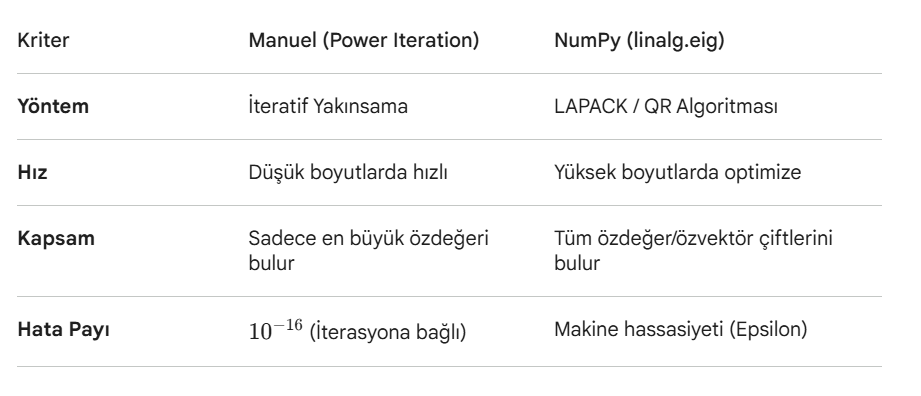

In [6]:
print(f"Manuel Hesaplanan En Büyük Özdeğer: {ozdeger_manuel}")
print(f"Manuel Hesaplanan Özvektör: {ozvektor_manuel}")
print(f"NumPy'ın En Büyük Özdeğeri: {ozdeger_np_max}")
print(f"NumPy'ın Karşılık Gelen Özvektörü: {ozvektor_np_max}")

Manuel Hesaplanan En Büyük Özdeğer: 5.0
Manuel Hesaplanan Özvektör: [0.89442719 0.4472136 ]
NumPy'ın En Büyük Özdeğeri: 5.0
NumPy'ın Karşılık Gelen Özvektörü: [0.89442719 0.4472136 ]
